## Charles Drost IV

Final project for COSC 440. Creates a custom controlPoints class and a dpAgent class. The dpAgents will compete and train in the controlPoints environment

In [ ]:
# Imports
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product

In [ ]:
# Statistics Tracking
agent1_wins = []         # 1 if agent1_id won, 0 otherwise
agent2_wins = []         # 1 if agent2_id won, 0 otherwise
p1_position_wins = []    # 1 if player 1 position won, 0 otherwise
p2_position_wins = []    # 1 if player 2 position won, 0 otherwise
ep_p1_unit_levels = []   # final p1unit_level at end of each episode
ep_p2_unit_levels = []   # final p2unit_level at end of each episode
ep_p1_resources = []     # final p1resources at end of each episode
ep_p2_resources = []     # final p2resources at end of each episode
ep_p1_unit_counts = []   # final total unit count for player 1
ep_p2_unit_counts = []   # final total unit count for player 2
ep_turns = []            # total turns taken per episode

In [ ]:
# Environment Class
class controlPoints:
    def __init__(self, seed=None, p1type='AI', p2type='AI', reward=100, penalty=-100, p1agent=None, p2agent=None, agent1_id=None, agent2_id=None):
        # Initializations
        if seed is not None:
            random.seed(seed)
        self.nodes = {i: {'units': [], 'owner': 0} for i in range(1, 17)}
        self.nodes[1]['owner'] = 1
        self.nodes[16]['owner'] = 2
        path_keys = [
            "1:2", "1:3", "2:3", "2:4", "2:5", "3:5", "3:6", "4:5", "4:7", "4:8",
            "5:6", "5:8", "5:9", "6:9", "6:10", "7:8", "7:11", "8:9", "8:11", "8:12",
            "9:10", "9:12", "9:13", "10:13", "11:12", "11:14", "12:13", "12:14", "12:15",
            "13:15", "14:15", "14:16", "15:16"
        ]
        self.paths = {k: [] for k in path_keys}
        self.p1actions = []
        self.p2actions = []
        self.p1resources = 0
        self.p2resources = 0
        self.p1unit_level = 1
        self.p2unit_level = 1
        self.reward = reward
        self.penalty = penalty
        self.p1type = p1type
        self.p2type = p2type
        self.p1agent = p1agent
        self.p2agent = p2agent
        self.agent1_id = agent1_id
        self.agent2_id = agent2_id
        self.p1turn_reward = 0
        self.p2turn_reward = 0
        self.game_over = False
        self.winner = None

    # --- Reset Environment ---
    def reset(self):
        # All variables should go back to starting values
        for i in range(1, 17):
            self.nodes[i]['units'] = []
            self.nodes[i]['owner'] = 0
        self.nodes[1]['owner'] = 1
        self.nodes[16]['owner'] = 2
        for k in self.paths:
            self.paths[k] = []
        self.p1actions = []
        self.p2actions = []
        self.p1resources = 0
        self.p2resources = 0
        self.p1unit_level = 1
        self.p2unit_level = 1
        self.game_over = False
        self.winner = None
        self.p1turn_reward = 0
        self.p2turn_reward = 0

    # --- Unit Creation ---
    def createUnit(self, team):
        # Determine home node and unit level
        if team == 1:
            node = 1
            level = self.p1unit_level
        elif team == 2:
            node = 16
            level = self.p2unit_level
        else:
            raise ValueError("Team must be 1 or 2")
        # Unit: [player, level, destination]
        unit = [team, level, 0]
        self.nodes[node]['units'].append(unit)

    # --- Battle Resolution ---
    def battle(self, node=0, path="0:0"):
        # Helper function to split units by player
        def split_units(units):
            p1 = [u for u in units if u[0] == 1]
            p2 = [u for u in units if u[0] == 2]
            return p1, p2

        # Get units to battle
        if node != 0:
            units = self.nodes[node]['units']
            p1units, p2units = split_units(units)
        elif path != "0:0":
            units = self.paths[path]
            p1units, p2units = split_units(units)
        else:
            return

        # Battle loop
        while p1units and p2units:
            u1 = p1units[0]
            u2 = p2units[0]
            # Reset battle variables
            skill1 = 5 * u1[1]
            skill2 = 5 * u2[1]
            power1 = 1
            power2 = 1
            # Power-up process
            while True:
                roll = random.randint(1, 100)
                if roll <= skill1:
                    power1 += 1
                    skill1 = math.ceil(skill1 / 2)
                else:
                    break
            while True:
                roll = random.randint(1, 100)
                if roll <= skill2:
                    power2 += 1
                    skill2 = math.ceil(skill2 / 2)
                else:
                    break
            # Compare power to determine which unit surives
            if power1 < power2:
                p1units.pop(0)
            elif power2 < power1:
                p2units.pop(0)
            else:
                # Tie: both survive, run it back
                pass
        # Place winner
        survivors = p1units + p2units
        if node != 0:
            self.nodes[node]['units'] = survivors
            # Set owner if winners exist (they always should)
            if survivors:
                self.nodes[node]['owner'] = survivors[0][0]
            else:
                self.nodes[node]['owner'] = 0
        elif path != "0:0":
            self.paths[path] = survivors
            if survivors:
                dest = survivors[0][2]
                if dest in self.nodes:
                    for u in survivors:
                        u[2] = 0
                    # Advance units to node if they battled on a path
                    self.nodes[dest]['units'].extend(survivors)
                self.paths[path] = []

    # --- Action Generation ---
    def getActions(self, player):
        actions = []
        # Determine needed variables
        resources = self.p1resources if player == 1 else self.p2resources
        unit_level = self.p1unit_level if player == 1 else self.p2unit_level
        player_type = self.p1type if player == 1 else self.p2type
        agent = self.p1agent if player == 1 else self.p2agent

        # Build initial options
        options = []
        if resources >= unit_level * 10:
            options.append('upgrade')
        if resources >= 10:
            options.append('buy_unit')
        player_nodes = [node for node, data in self.nodes.items() if any(u[0] == player for u in data['units'])]

        # Human option displays
        if player_type == 'human':
            # Find out where player wants to move from
            options += [str(n) for n in player_nodes]
            print(f"\nPlayer {player}, available actions: {options}")
            chosen_raw = input(f"Player {player}, choose actions (comma-separated): ").split(",")
            chosen = [c.strip() for c in chosen_raw]
            # Loop through chosen nodes and find their connecting nodes, then confirm what actions to do from those nodes with the player
            for choice in chosen:
                if choice == 'upgrade':
                    actions.append('upgrade')
                elif choice == 'buy_unit':
                    actions.append('buy_unit')
                elif choice.isdigit() and int(choice) in player_nodes:
                    node = int(choice)
                    count = len([u for u in self.nodes[node]['units'] if u[0] == player])
                    connecting_nodes = []
                    for path_key in self.paths:
                        parts = [int(x) for x in path_key.split(':')]
                        if node in parts:
                            other = parts[1] if parts[0] == node else parts[0]
                            if other not in connecting_nodes:
                                connecting_nodes.append(other)
                    print(f"  Node {node} has {count} unit(s). Connecting nodes: {connecting_nodes}.")
                    moves_raw = input(f"  Enter movements from node {node} as '{{n}}to{{dest}}', comma-separated (blank to skip): ")
                    if moves_raw.strip():
                        for move in moves_raw.split(","):
                            move = move.strip()
                            if "to" in move:
                                try:
                                    num, dest = move.split("to")
                                    num = num.strip()
                                    dest = dest.strip()
                                    actions.append(f"{num}from{node}to{dest}")
                                except ValueError:
                                    pass
        # AI options sends info to agent
        else:
            state = self.getState(player)
            avail_actions = []
            # For player 2, actions must be in relative coordinates (node 1 is home)
            if player == 2:
                # For each node, add possible moves
                for abs_node in player_nodes:
                    rel_src = 17 - abs_node
                    # Find connecting nodes in absolute, then map to relative
                    for path_key in self.paths:
                        parts = [int(x) for x in path_key.split(':')]
                        if abs_node in parts:
                            abs_other = parts[1] if parts[0] == abs_node else parts[0]
                            rel_dst = 17 - abs_other
                            count = len([u for u in self.nodes[abs_node]['units'] if u[0] == player])
                            for n in range(1, count + 1):
                                avail_actions.append(f"{n}from{rel_src}to{rel_dst}")
                # Add the non-movement actions
                for act in options:
                    if act in ('buy_unit', 'upgrade'):
                        avail_actions.insert(0, act)
            else:
                # Player 1: normal numbering
                avail_actions = []
                for act in options:
                    if act in ('upgrade', 'buy_unit'):
                        avail_actions.append(act)
                for node in player_nodes:
                    for path_key in self.paths:
                        parts = [int(x) for x in path_key.split(':')]
                        if node in parts:
                            other = parts[1] if parts[0] == node else parts[0]
                            count = len([u for u in self.nodes[node]['units'] if u[0] == player])
                            for n in range(1, count + 1):
                                avail_actions.append(f"{n}from{node}to{other}")

            # --- Sort the actions to be the same for both players to remove order bias oh my lord this took so long to find ---
            avail_actions = sorted(avail_actions)
            # Agent chooses actions in relative coordinates
            chosen = agent.decideActions(avail_actions, state)
            # For player 2, translate actions back to absolute coordinates
            if player == 2:
                abs_actions = []
                for act in chosen:
                    if act in ('upgrade', 'buy_unit'):
                        abs_actions.append(act)
                    elif "from" in act and "to" in act:
                        try:
                            num, rest = act.split("from")
                            num = num.strip()
                            src, dst = rest.split("to")
                            src = int(src)
                            dst = int(dst)
                            abs_src = 17 - src
                            abs_dst = 17 - dst
                            abs_actions.append(f"{num}from{abs_src}to{abs_dst}")
                        except Exception:
                            continue
                    elif act.isdigit():
                        abs_actions.append(str(17 - int(act)))
                actions = abs_actions
            else:
                actions = chosen
        # Add actions to respective player's action list
        if player == 1:
            self.p1actions = actions
        else:
            self.p2actions = actions
        return actions

    # --- Action Execution ---
    def doActions(self):
        # Randomize which player's actions go first (even though it shouldn't matter)
        order = [1, 2]
        random.shuffle(order)
        for player in order:
            actions = self.p1actions if player == 1 else self.p2actions
            i = 0
            while i < len(actions):
                action = actions[i]
                # Apply upgrades
                if action == "upgrade":
                    if player == 1:
                        cost = self.p1unit_level * 10
                        if self.p1resources >= cost:
                            self.p1resources -= cost
                            self.p1unit_level += 1
                            self.p1turn_reward += 1
                            for node in self.nodes.values():
                                for u in node['units']:
                                    if u[0] == 1:
                                        u[1] += 1
                        actions.pop(i)
                        continue
                    else:
                        cost = self.p2unit_level * 10
                        if self.p2resources >= cost:
                            self.p2resources -= cost
                            self.p2unit_level += 1
                            self.p2turn_reward += 1
                            for node in self.nodes.values():
                                for u in node['units']:
                                    if u[0] == 2:
                                        u[1] += 1
                        actions.pop(i)
                        continue
                # Place bought units at homes
                elif action == "buy_unit":
                    if player == 1:
                        if self.p1resources >= 10:
                            self.p1resources -= 10
                            self.createUnit(1)
                        actions.pop(i)
                        continue
                    else:
                        if self.p2resources >= 10:
                            self.p2resources -= 10
                            self.createUnit(2)
                        actions.pop(i)
                        continue
                # Do movement actions into paths based and set destinations
                elif "from" in action and "to" in action:
                    try:
                        num, rest = action.split("from")
                        num = int(num)
                        src, dst = rest.split("to")
                        src = int(src)
                        dst = int(dst)
                        src_units = [u for u in self.nodes[src]['units'] if u[0] == player]
                        if len(src_units) < num:
                            actions.pop(i)
                            continue
                        moved = 0
                        for u in self.nodes[src]['units']:
                            if u[0] == player and moved < num:
                                u[2] = dst
                                moved += 1
                        found = False
                        for path in self.paths:
                            nodes_in_path = [int(x) for x in path.split(":")]
                            if src in nodes_in_path and dst in nodes_in_path:
                                to_move = []
                                for u in self.nodes[src]['units']:
                                    if u[0] == player and u[2] == dst:
                                        to_move.append(u)
                                for u in to_move:
                                    self.paths[path].append(u)
                                    self.nodes[src]['units'].remove(u)
                                found = True
                                break
                        if not found:
                            for u in self.nodes[src]['units']:
                                if u[0] == player and u[2] == dst:
                                    u[2] = 0
                        actions.pop(i)
                        continue
                    except Exception:
                        actions.pop(i)
                        continue
                else:
                    i += 1
        self.p1actions = []
        self.p2actions = []

    # --- State Advancement ---
    def advanceState(self):
        # Track node ownership before
        prev_owners = {n: d['owner'] for n, d in self.nodes.items()}
        # Resolve battles on paths
        for path, units in self.paths.items():
            if units:
                p1 = any(u[0] == 1 for u in units)
                p2 = any(u[0] == 2 for u in units)
                if p1 and p2:
                    self.battle(path=path)
                else:
                    # Move units to destination node
                    if units:
                        dest = units[0][2]
                        if dest in self.nodes:
                            for u in units:
                                u[2] = 0
                            self.nodes[dest]['units'].extend(units)
                        self.paths[path] = []
        # Resolve battles on nodes
        for node, data in self.nodes.items():
            units = data['units']
            if units:
                p1 = any(u[0] == 1 for u in units)
                p2 = any(u[0] == 2 for u in units)
                if p1 and p2:
                    self.battle(node=node)
                elif p1:
                    data['owner'] = 1
                elif p2:
                    data['owner'] = 2
        # Track node ownership after
        new_owners = {n: d['owner'] for n, d in self.nodes.items()}
        # Compute per-turn rewards
        self.p1turn_reward = 0
        self.p2turn_reward = 0
        for n in self.nodes:
            before = prev_owners[n]
            after = new_owners[n]
            if before != 1 and after == 1:
                self.p1turn_reward += 2
            if before == 1 and after != 1:
                self.p1turn_reward -= 2
            if before != 2 and after == 2:
                self.p2turn_reward += 2
            if before == 2 and after != 2:
                self.p2turn_reward -= 2
        # Check for win condition
        p1_home_captured = self.nodes[16]['owner'] == 1
        p2_home_captured = self.nodes[1]['owner'] == 2
        if p1_home_captured and p2_home_captured:
            # Declare draw if both homes are captures simultaneously
            self.game_over = True
            self.winner = 0
        elif p2_home_captured:
            self.game_over = True
            self.winner = 2
        elif p1_home_captured:
            self.game_over = True
            self.winner = 1

    # --- State Retrieval ---
    def getState(self, player=1):
        # Player 1: normal state
        if player == 1:
            return {
                'nodes': {n: {'units': [u[:] for u in d['units']], 'owner': d['owner']} for n, d in self.nodes.items()},
                'p1unit_level': self.p1unit_level,
                'p2unit_level': self.p2unit_level,
                'p1resources': self.p1resources,
                'p2resources': self.p2resources,
            }
        # Player 2: mirrored state
        else:
            # Map node numbers: 1<->16, 2<->15, ..., 16<->1
            node_map = {i: 17 - i for i in range(1, 17)}
            rel_nodes = {}
            for abs_n in range(1, 17):
                rel_n = node_map[abs_n]
                abs_data = self.nodes[abs_n]
                # Swap owner: 1<->2, 0 stays 0
                owner = abs_data['owner']
                if owner == 1:
                    rel_owner = 2
                elif owner == 2:
                    rel_owner = 1
                else:
                    rel_owner = 0
                # Units: swap player numbers in units
                rel_units = []
                for u in abs_data['units']:
                    rel_player = 2 if u[0] == 1 else 1 if u[0] == 2 else 0
                    rel_dest = (17 - u[2]) if u[2] != 0 else 0
                    rel_units.append([rel_player, u[1], rel_dest])
                rel_nodes[rel_n] = {'units': rel_units, 'owner': rel_owner}
            rel_nodes = dict(reversed(rel_nodes.items()))
            return {
                'nodes': rel_nodes,
                'p1unit_level': self.p2unit_level,
                'p2unit_level': self.p1unit_level,
                'p1resources': self.p2resources,
                'p2resources': self.p1resources,
            }

    # --- Visualization ---
    def displayState(self, state):
        # Matplotlib is a magical creation and we should all be greatful that this is possible
        positions = {
            1: (0, 6),
            2: (-1, 5), 3: (1, 5),
            4: (-2, 4), 5: (0, 4), 6: (2, 4),
            7: (-3, 3), 8: (-1, 3), 9: (1, 3), 10: (3, 3),
            11: (-2, 2), 12: (0, 2), 13: (2, 2),
            14: (-1, 1), 15: (1, 1),
            16: (0, 0)
        }
        fig, ax = plt.subplots(figsize=(8, 8))
        # Plot paths
        for path in self.paths:
            n1, n2 = [int(x) for x in path.split(":")]
            x1, y1 = positions[n1]
            x2, y2 = positions[n2]
            ax.plot([x1, x2], [y1, y2], color='black', zorder=1)
        # Plot nodes, color based on team, and number according to node number and unit count
        for node, (x, y) in positions.items():
            owner = state['nodes'][node]['owner']
            color = 'grey'
            if owner == 1:
                color = 'blue'
            elif owner == 2:
                color = 'red'
            ax.scatter(x, y, s=800, color=color, edgecolors='black', zorder=2)
            if node == 1 or node == 16:
                ax.text(x, y, str(len(state['nodes'][node]['units']) + 5), color='white', ha='center', va='center', fontsize=14, fontweight='bold', zorder=3)
            else:
                ax.text(x, y, str(len(state['nodes'][node]['units'])), color='white', ha='center', va='center', fontsize=14, fontweight='bold', zorder=3)
            ax.text(x, y-0.5, f"Node {node}", color='black', ha='center', va='center', fontsize=10, zorder=4)
        ax.set_aspect('equal')
        ax.axis('off')
        # Show other statistics in title
        plt.title(f"Control Points State\nP1 Level: {self.p1unit_level} | P1 Resources: {self.p1resources} | "f"P2 Level: {self.p2unit_level} | P2 Resources: {self.p2resources}")
        plt.show()
        plt.close(fig)

    # --- Main Game Loop ---
    def playGame(self):
        self.reset()
        # Start AIs
        if self.p1type == 'AI' and self.p1agent is not None:
            self.p1agent.new_episode()
        if self.p2type == 'AI' and self.p2agent is not None:
            self.p2agent.new_episode()
        # Display initial state if there is a human player
        if self.p1type == 'human' or self.p2type == 'human':
                self.displayState(self.getState(1))
        turn = 1
        #time_reward = 200 # Extra reward for winning games quickly
        last_p1_state, last_p1_actions = None, None
        last_p2_state, last_p2_actions = None, None
        # Actual loop part
        while not self.game_over:
            self.p1turn_reward = 0
            self.p2turn_reward = 0
            for _ in range(5):
                self.createUnit(1)
                self.createUnit(2)
            self.getActions(1)
            self.getActions(2)
            self.doActions()
            self.advanceState()
            if not self.game_over:
                p1_owned = sum(1 for n in self.nodes.values() if n['owner'] == 1)
                p2_owned = sum(1 for n in self.nodes.values() if n['owner'] == 2)
                self.p1resources += p1_owned
                self.p2resources += p2_owned
            # Per-turn RL update
            if self.p1type == 'AI' and self.p1agent is not None:
                self.p1agent.update(self.p1turn_reward, self.getState(1))
            if self.p2type == 'AI' and self.p2agent is not None:
                self.p2agent.update(self.p2turn_reward, self.getState(2))
            # Display state if there is a human player
            if self.p1type == 'human' or self.p2type == 'human':
                self.displayState(self.getState(1))
            turn += 1
            #time_reward *= 0.99 # Reduce time reward for playing more turns
            if self.p1type == 'AI' and self.p1agent is not None and last_p1_state is not None and last_p1_actions is not None and len(last_p1_actions) > 0:
                self.p1agent.update_terminal(self.reward if self.winner == 1 else self.penalty if self.winner == 2 else 0, self.getState(1), last_p1_state, last_p1_actions)
            if self.p2type == 'AI' and self.p2agent is not None and last_p2_state is not None and last_p2_actions is not None and len(last_p2_actions) > 0:
                self.p2agent.update_terminal(self.reward if self.winner == 2 else self.penalty if self.winner == 1 else 0, self.getState(2), last_p2_state, last_p2_actions)
        # End-game RL update
        #self.reward += time_reward # Add time reward to winning reward
        # I did realize this code is redundant and (I think) applies the reward twice but it's a bit late to fix that as this comment is the last thing I'm doing
        if self.p1type == 'AI' and self.p1agent is not None:
            self.p1agent.update(self.reward if self.winner == 1 else self.penalty, self.getState(1))
        if self.p2type == 'AI' and self.p2agent is not None:
            self.p2agent.update(self.reward if self.winner == 2 else self.penalty, self.getState(2))
        #print(f"Game Over! Winner: Player {self.winner}")
        #if self.winner == 1 and self.p1type == 'AI':
        #    print(f"Player 1 receives reward: {self.reward}")
        #elif self.winner == 2 and self.p2type == 'AI':
        #    print(f"Player 2 receives reward: {self.reward}")

        # Update statistics
        ep_turns.append(turn)
        ep_p1_unit_levels.append(self.p1unit_level)
        ep_p2_unit_levels.append(self.p2unit_level)
        ep_p1_resources.append(self.p1resources)
        ep_p2_resources.append(self.p2resources)
        p1_count = sum(len([u for u in d['units'] if u[0]==1]) for d in self.nodes.values())
        p2_count = sum(len([u for u in d['units'] if u[0]==2]) for d in self.nodes.values())
        ep_p1_unit_counts.append(p1_count)
        ep_p2_unit_counts.append(p2_count)
        p1_position_wins.append(1 if self.winner==1 else 0)
        p2_position_wins.append(1 if self.winner==2 else 0)
        # Agent win attribution
        if self.winner == 1:
            if self.agent1_id is not None and self.agent2_id is not None:
                if self.agent1_id == 'A':
                    agent1_wins.append(1)
                    agent2_wins.append(0)
                else:
                    agent1_wins.append(0)
                    agent2_wins.append(1)
        elif self.winner == 2:
            if self.agent1_id is not None and self.agent2_id is not None:
                if self.agent2_id == 'A':
                    agent1_wins.append(1)
                    agent2_wins.append(0)
                else:
                    agent1_wins.append(0)
                    agent2_wins.append(1)
        else:  # Draw
            p1_position_wins.append(0)
            p2_position_wins.append(0)
            agent1_wins.append(0)
            agent2_wins.append(0)

In [ ]:
class dpAgent:
    def __init__(self, alpha, epsilon, epsilon_decay, min_epsilon=0.01, policy=None, seed=None):
        # Initializations
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.gamma = 0.99
        self.policy = policy if policy is not None else defaultdict(lambda: defaultdict(float))
        self.last_state = None
        self.last_actions = None
        self.rng = random.Random(seed) if seed is not None else random

    def _state_to_key(self, state):
        # Bucket resources because that would be too much for the AI to handle
        owners = tuple(state['nodes'][i]['owner'] for i in range(1, 17))
        def bucket(r):
            if r == 0: return 0
            elif r <= 10: return 1
            elif r <= 20: return 2
            elif r <= 50: return 3
            else: return 4
        return (owners, state['p1unit_level'], bucket(state['p1resources']))

    def decideActions(self, actions, state):
        # Shuffle based on seed to encourage an actual strategy rather than hope what you pick first works
        self.rng.shuffle(actions)
        state_key = self._state_to_key(state)
        chosen = []
        # Check epsilon and either explore or don't
        for action in actions:
            if self.rng.random() < self.epsilon:
                if self.rng.random() < 0.5:
                    chosen.append(action)
            else:
                if self.policy[state_key][action] > 0:
                    chosen.append(action)
        self.last_state = state_key
        self.last_actions = tuple(chosen)
        return chosen

    def update(self, reward, state):
        if self.last_state is None or self.last_actions is None:
            self.last_state = self._state_to_key(state)
            self.last_actions = tuple()
            return
        # Keep track of states
        state_key = self._state_to_key(state)
        next_q = 0.0
        if self.policy[state_key]:
            next_q = max(self.policy[state_key].values())
        # Q-learning update for each individual action taken
        for action in self.last_actions:
            last_q = self.policy[self.last_state][action]
            self.policy[self.last_state][action] += self.alpha * (reward + self.gamma * next_q - last_q)
        # Epsilon Decay
        self.epsilon = max(self.min_epsilon, self.epsilon * (1 - self.epsilon_decay))
        self.last_state = state_key
        self.last_actions = tuple()

    def update_terminal(self, reward, state, last_state, last_actions):
        # Special update for final state because of how states and actions are reset
        state_key = self._state_to_key(state)
        next_q = 0.0
        if self.policy[state_key]:
            next_q = max(self.policy[state_key].values())
        for action in last_actions:
            last_q = self.policy[last_state][action]
            self.policy[last_state][action] += self.alpha * (reward + self.gamma * next_q - last_q)
        self.epsilon = max(self.min_epsilon, self.epsilon * (1 - self.epsilon_decay))

    def new_episode(self):
        self.last_state = None
        self.last_actions = None

50 episodes complete. Agent A total wins: 23. Agent B total wins: 27.
100 episodes complete. Agent A total wins: 43. Agent B total wins: 57.
150 episodes complete. Agent A total wins: 61. Agent B total wins: 89.
200 episodes complete. Agent A total wins: 83. Agent B total wins: 117.
250 episodes complete. Agent A total wins: 110. Agent B total wins: 140.
300 episodes complete. Agent A total wins: 140. Agent B total wins: 160.
350 episodes complete. Agent A total wins: 169. Agent B total wins: 181.
400 episodes complete. Agent A total wins: 203. Agent B total wins: 197.
450 episodes complete. Agent A total wins: 230. Agent B total wins: 220.
500 episodes complete. Agent A total wins: 259. Agent B total wins: 241.
550 episodes complete. Agent A total wins: 284. Agent B total wins: 266.
600 episodes complete. Agent A total wins: 307. Agent B total wins: 293.
650 episodes complete. Agent A total wins: 336. Agent B total wins: 314.
700 episodes complete. Agent A total wins: 355. Agent B tot

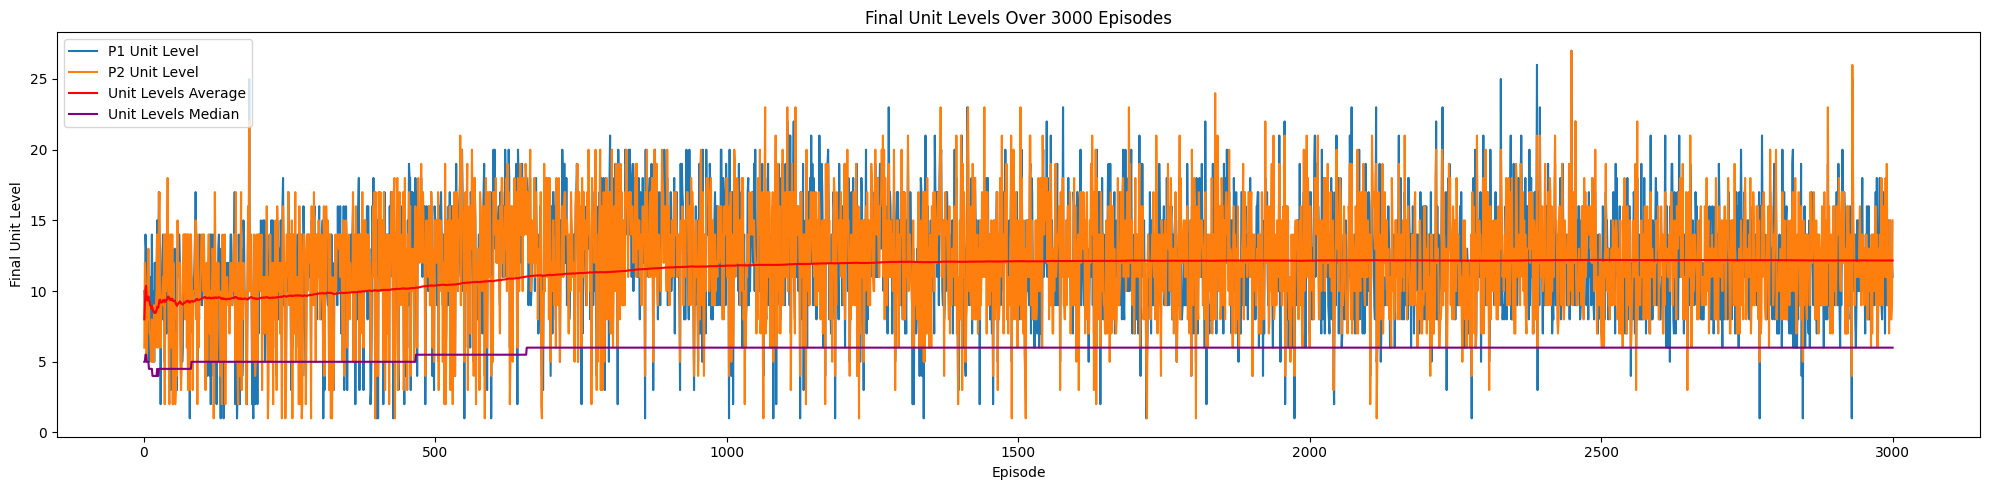

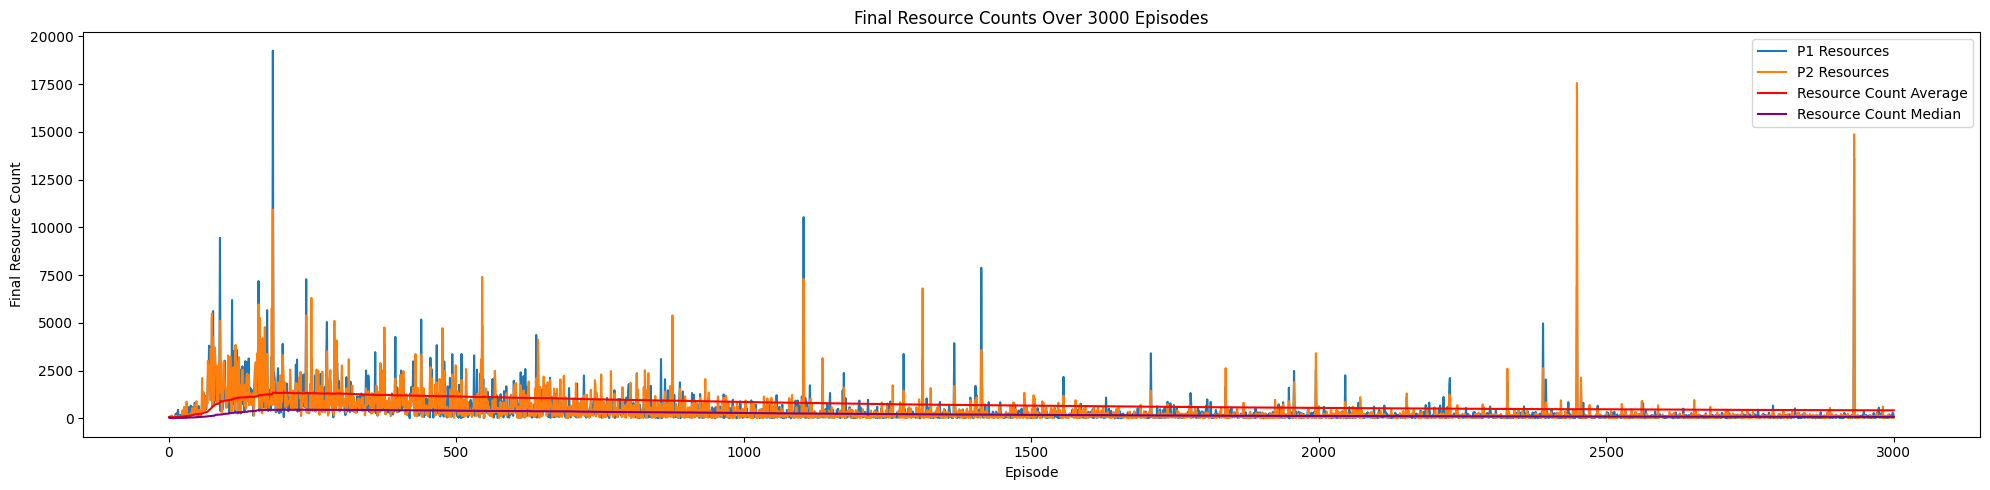

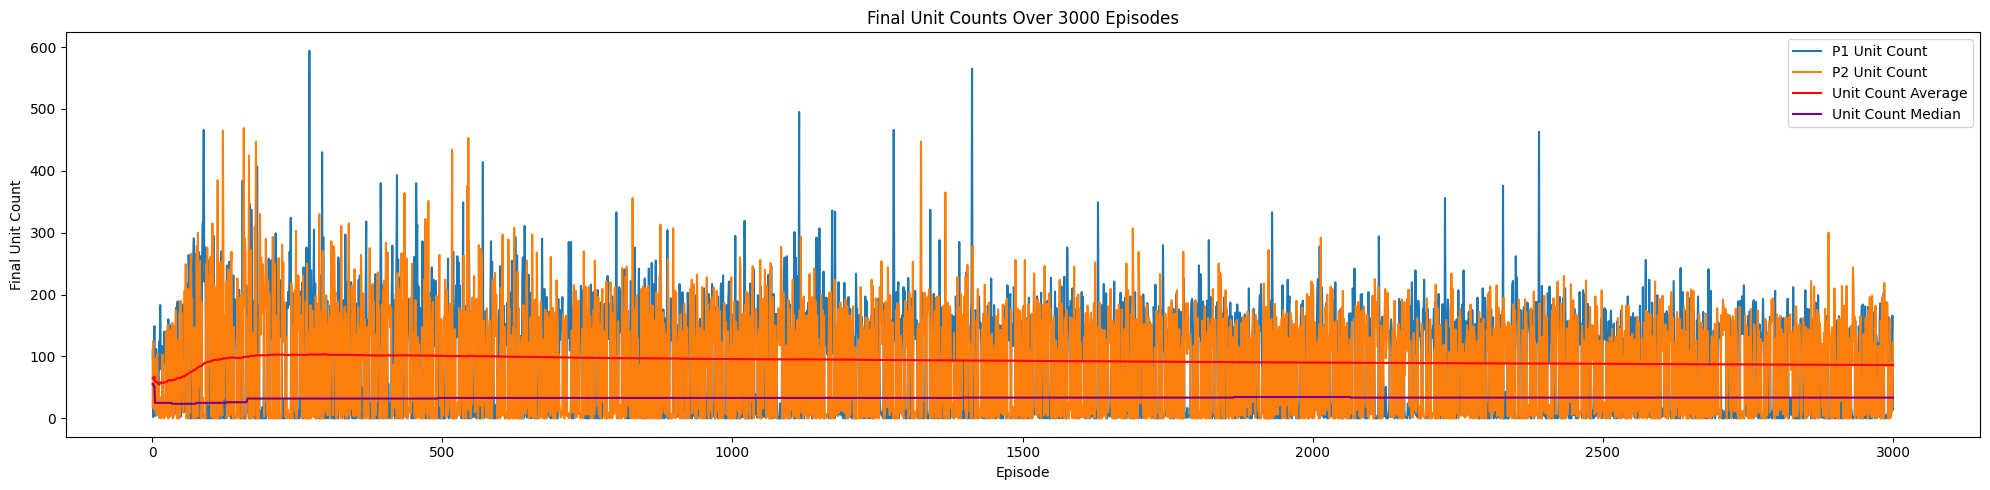

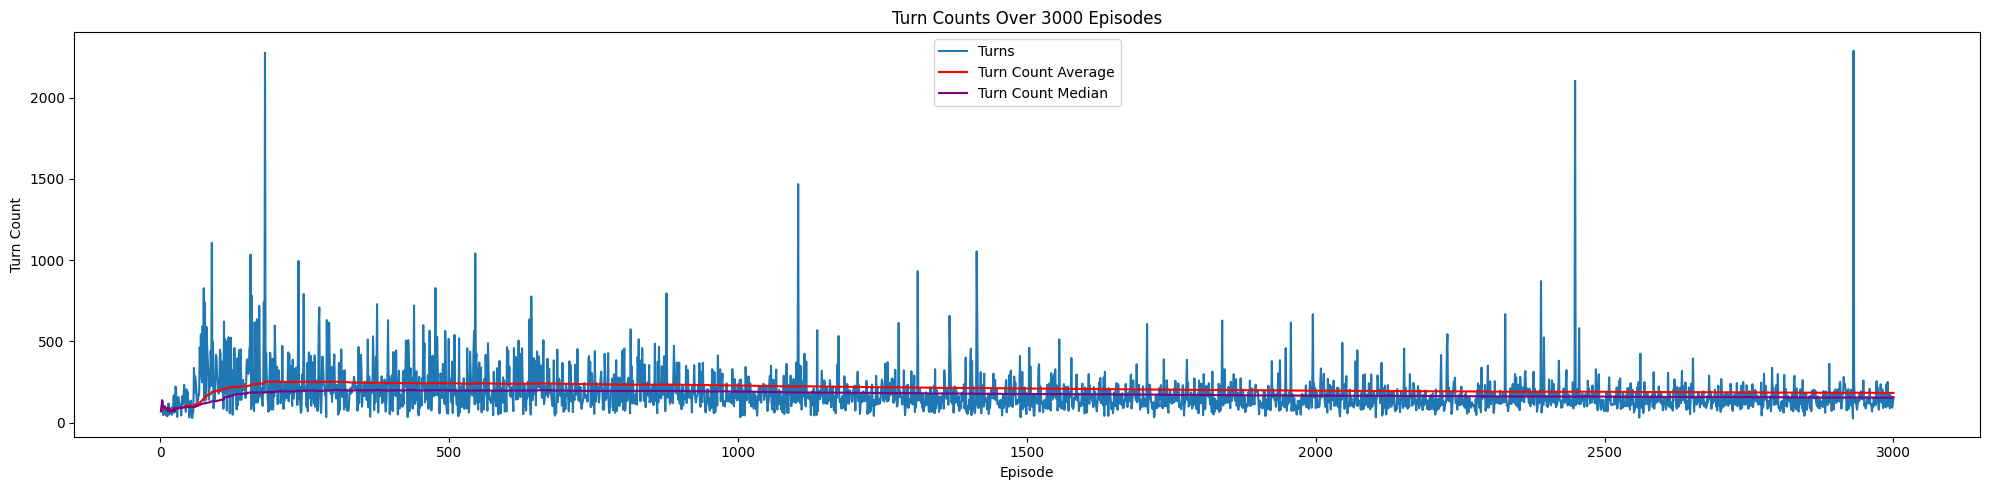

In [ ]:
# Implementation
if __name__ == "__main__":
    agent_A = dpAgent(alpha=0.1, epsilon=0.5, epsilon_decay=0.0005, min_epsilon=0.005, seed=1)
    agent_B = dpAgent(alpha=0.1, epsilon=0.5, epsilon_decay=0.0005, min_epsilon=0.005, seed=2)
    episode_count = 3000
    for i in range(episode_count):
        if i % 2 == 0:
            # Agent A is player 1, Agent B is player 2
            game = controlPoints(p1type='AI', p2type='AI', p1agent=agent_A, p2agent=agent_B, agent1_id='A', agent2_id='B', seed=i)
        else:
            # Agent B is player 1, Agent A is player 2
            game = controlPoints(p1type='AI', p2type='AI', p1agent=agent_B, p2agent=agent_A, agent1_id='B', agent2_id='A', seed=i)
        game.playGame()
        if i % 50 == 49:
            # Print a progress report
            print(f"{i + 1} episodes complete. Agent A total wins: {sum(agent1_wins)}. Agent B total wins: {sum(agent2_wins)}.")

    print(f"Agent A total wins: {sum(agent1_wins)}")
    print(f"Agent B total wins: {sum(agent2_wins)}")
    print(f"Player 1 position wins: {sum(p1_position_wins)}")
    print(f"Player 2 position wins: {sum(p2_position_wins)}")

    # === PLOTS ===
    episodes = list(range(1, len(ep_p1_unit_levels)+1))

    # Calculate averages and medians of each value and add them to their own lists to add to the datasets
    unit_levels_avg = []
    unit_levels_median = []
    resource_count_avg = []
    resource_count_median = []
    unit_count_avg = []
    unit_count_median = []
    turn_count_avg = []
    turn_count_median = []
    for i in range(1, episode_count + 1):
        unit_levels_avg.append((sum(ep_p1_unit_levels[:i]) + sum(ep_p2_unit_levels[:i])) / (2 * i))
        unit_levels_median.append(sorted((ep_p1_unit_levels[:i]) + ep_p2_unit_levels[:i])[round(i)] / 2)
        resource_count_avg.append((sum(ep_p1_resources[:i]) + sum(ep_p2_resources[:i])) / (2 * i))
        resource_count_median.append(sorted((ep_p1_resources[:i]) + ep_p2_resources[:i])[round(i)] / 2)
        unit_count_avg.append((sum(ep_p1_unit_counts[:i]) + sum(ep_p2_unit_counts[:i])) / (2 * i))
        unit_count_median.append(sorted((ep_p1_unit_counts[:i]) + ep_p2_unit_counts[:i])[round(i)] / 2)
        turn_count_avg.append(sum(ep_turns[:i]) / i)
        turn_count_median.append(sorted(ep_turns[:i])[round(i/2)])

    # Figure 1: Final Unit Levels
    plt.figure(figsize=(20,5))
    plt.plot(episodes, ep_p1_unit_levels, label="P1 Unit Level")
    plt.plot(episodes, ep_p2_unit_levels, label="P2 Unit Level")
    plt.plot(episodes, unit_levels_avg, label="Unit Levels Average", color='Red')
    plt.plot(episodes, unit_levels_median, label="Unit Levels Median", color='Purple')
    plt.xlabel("Episode")
    plt.ylabel("Final Unit Level")
    plt.title(f"Final Unit Levels Over {episode_count} Episodes")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Figure 2: Final Resource Counts
    plt.figure(figsize=(20,5))
    plt.plot(episodes, ep_p1_resources, label="P1 Resources")
    plt.plot(episodes, ep_p2_resources, label="P2 Resources")
    plt.plot(episodes, resource_count_avg, label="Resource Count Average", color='Red')
    plt.plot(episodes, resource_count_median, label="Resource Count Median", color='Purple')
    plt.xlabel("Episode")
    plt.ylabel("Final Resource Count")
    plt.title(f"Final Resource Counts Over {episode_count} Episodes")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Figure 3: Final Unit Counts
    plt.figure(figsize=(20,5))
    plt.plot(episodes, ep_p1_unit_counts, label="P1 Unit Count")
    plt.plot(episodes, ep_p2_unit_counts, label="P2 Unit Count")
    plt.plot(episodes, unit_count_avg, label="Unit Count Average", color='Red')
    plt.plot(episodes, unit_count_median, label="Unit Count Median", color='Purple')
    plt.xlabel("Episode")
    plt.ylabel("Final Unit Count")
    plt.title(f"Final Unit Counts Over {episode_count} Episodes")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Figure 4: Turn Counts
    plt.figure(figsize=(20,5))
    plt.plot(episodes, ep_turns, label="Turns")
    plt.plot(episodes, turn_count_avg, label="Turn Count Average", color='Red')
    plt.plot(episodes, turn_count_median, label="Turn Count Median", color='Purple')
    plt.xlabel("Episode")
    plt.ylabel("Turn Count")
    plt.title(f"Turn Counts Over {episode_count} Episodes")
    plt.legend()
    plt.tight_layout()
    plt.show()

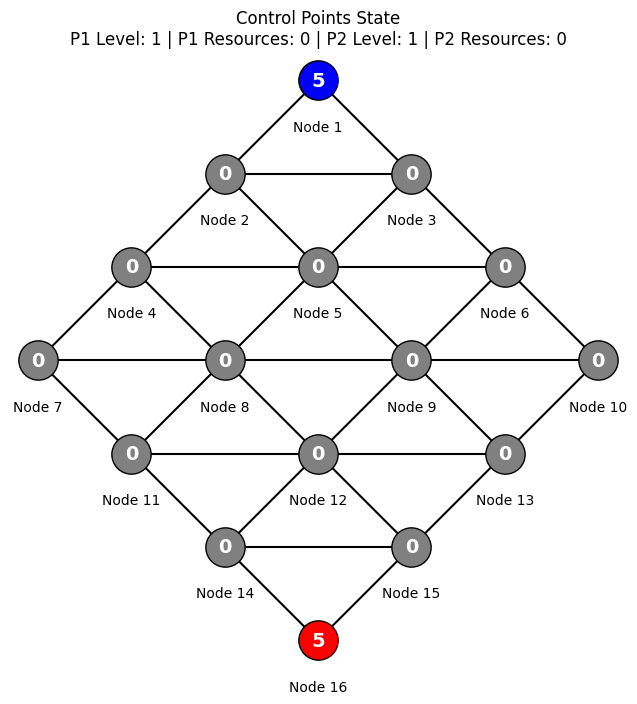


Player 1, available actions: ['1']
Player 1, choose actions (comma-separated): 1
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 2to2,3to3


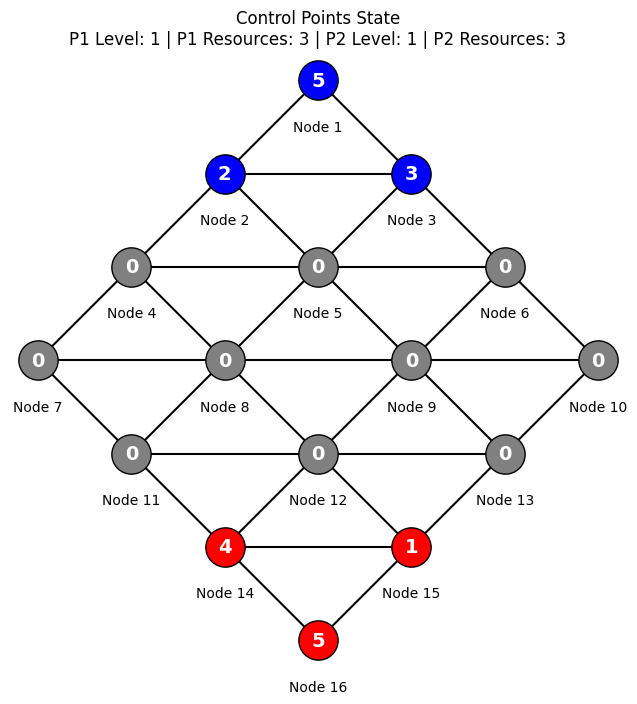


Player 1, available actions: ['1', '2', '3']
Player 1, choose actions (comma-separated): 1, 2, 3
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 3to2, 2to3
  Node 2 has 2 unit(s). Connecting nodes: [1, 3, 4, 5].
  Enter movements from node 2 as '{n}to{dest}', comma-separated (blank to skip): 2to4
  Node 3 has 3 unit(s). Connecting nodes: [1, 2, 5, 6].
  Enter movements from node 3 as '{n}to{dest}', comma-separated (blank to skip): 2to5,1to6


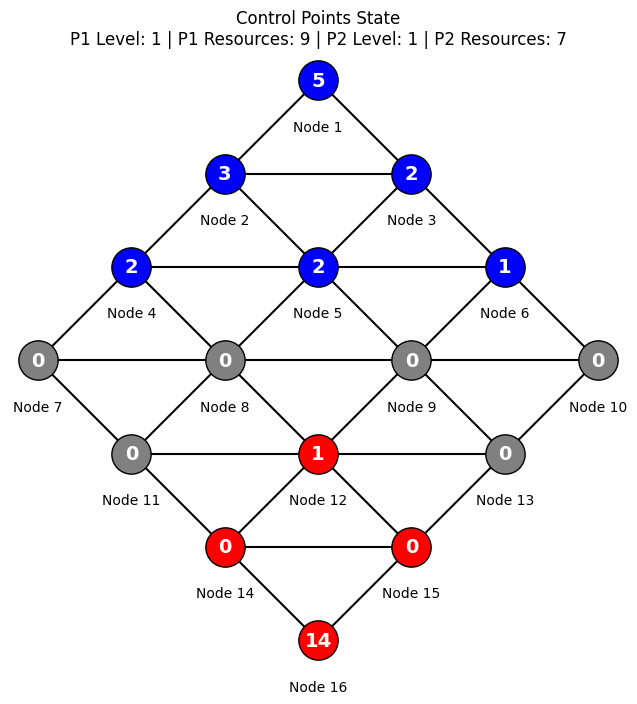


Player 1, available actions: ['1', '2', '3', '4', '5', '6']
Player 1, choose actions (comma-separated): 1,2,3,4,5,6
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 2to2,3to3
  Node 2 has 3 unit(s). Connecting nodes: [1, 3, 4, 5].
  Enter movements from node 2 as '{n}to{dest}', comma-separated (blank to skip): 1to4,2to5
  Node 3 has 2 unit(s). Connecting nodes: [1, 2, 5, 6].
  Enter movements from node 3 as '{n}to{dest}', comma-separated (blank to skip): 2to6
  Node 4 has 2 unit(s). Connecting nodes: [2, 5, 7, 8].
  Enter movements from node 4 as '{n}to{dest}', comma-separated (blank to skip): 1to7,1to8
  Node 5 has 2 unit(s). Connecting nodes: [2, 3, 4, 6, 8, 9].
  Enter movements from node 5 as '{n}to{dest}', comma-separated (blank to skip): 1to8,1to9
  Node 6 has 1 unit(s). Connecting nodes: [3, 5, 9, 10].
  Enter movements from node 6 as '{n}to{dest}', comma-separated (blank to skip): 1to10


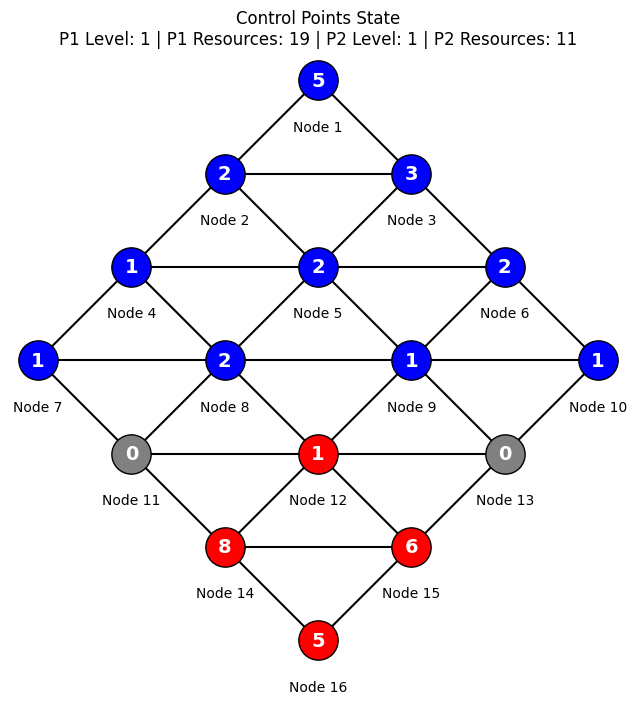


Player 1, available actions: ['upgrade', 'buy_unit', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Player 1, choose actions (comma-separated): upgrade,1,2,3,4,5,6,7,8,9,10
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 3to2,2to3
  Node 2 has 2 unit(s). Connecting nodes: [1, 3, 4, 5].
  Enter movements from node 2 as '{n}to{dest}', comma-separated (blank to skip): 1to4,1to5
  Node 3 has 3 unit(s). Connecting nodes: [1, 2, 5, 6].
  Enter movements from node 3 as '{n}to{dest}', comma-separated (blank to skip): 2to5,1to6
  Node 4 has 1 unit(s). Connecting nodes: [2, 5, 7, 8].
  Enter movements from node 4 as '{n}to{dest}', comma-separated (blank to skip): 1to8
  Node 5 has 2 unit(s). Connecting nodes: [2, 3, 4, 6, 8, 9].
  Enter movements from node 5 as '{n}to{dest}', comma-separated (blank to skip): 1to8,1to9
  Node 6 has 2 unit(s). Connecting nodes: [3, 5, 9, 10].
  Enter movements from node 6 as '{

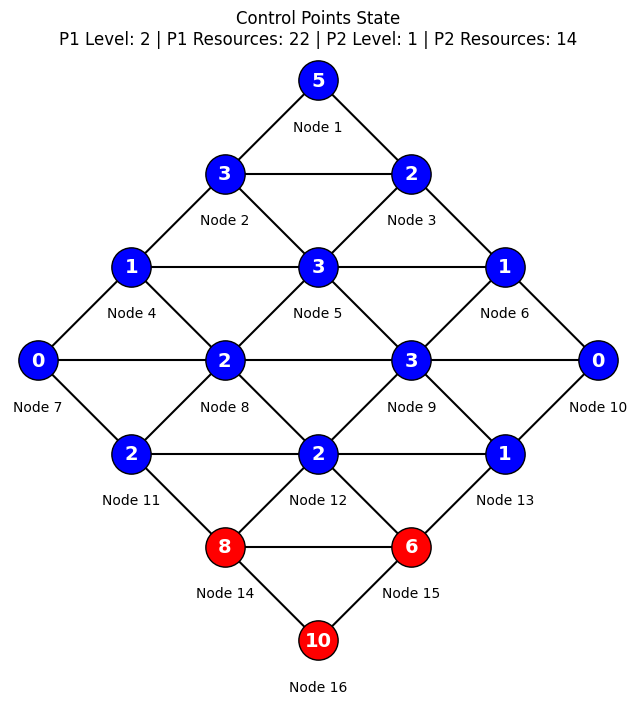


Player 1, available actions: ['upgrade', 'buy_unit', '1', '2', '3', '4', '5', '6', '8', '9', '11', '12', '13']
Player 1, choose actions (comma-separated): upgrade,1,2,3,4,5,6,8,9,11,12,13
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 5to2
  Node 2 has 3 unit(s). Connecting nodes: [1, 3, 4, 5].
  Enter movements from node 2 as '{n}to{dest}', comma-separated (blank to skip): 3to5
  Node 3 has 2 unit(s). Connecting nodes: [1, 2, 5, 6].
  Enter movements from node 3 as '{n}to{dest}', comma-separated (blank to skip): 2to5
  Node 4 has 1 unit(s). Connecting nodes: [2, 5, 7, 8].
  Enter movements from node 4 as '{n}to{dest}', comma-separated (blank to skip): 1to8
  Node 5 has 3 unit(s). Connecting nodes: [2, 3, 4, 6, 8, 9].
  Enter movements from node 5 as '{n}to{dest}', comma-separated (blank to skip): 2to8,1to9
  Node 6 has 1 unit(s). Connecting nodes: [3, 5, 9, 10].
  Enter movements from node 6 as '{n}to

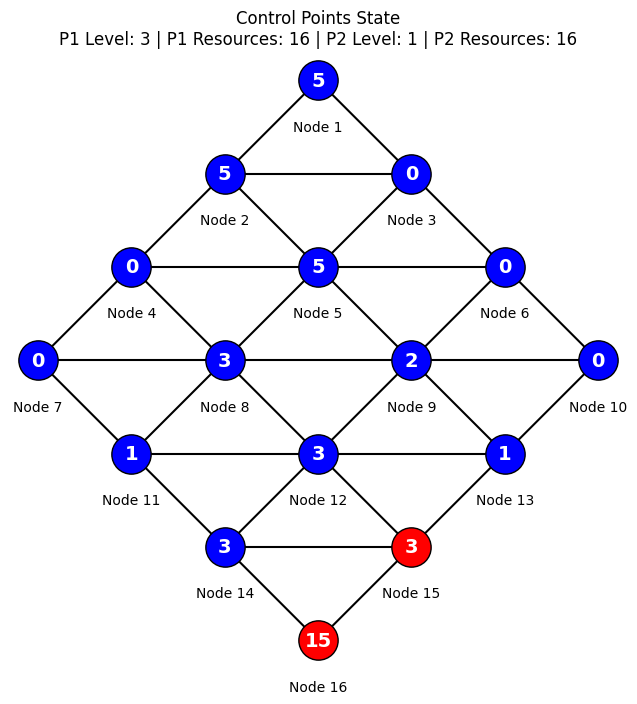


Player 1, available actions: ['buy_unit', '1', '2', '5', '8', '9', '11', '12', '13', '14']
Player 1, choose actions (comma-separated): 1,2,5,8,9,11,12,13,14
  Node 1 has 5 unit(s). Connecting nodes: [2, 3].
  Enter movements from node 1 as '{n}to{dest}', comma-separated (blank to skip): 5to3
  Node 2 has 5 unit(s). Connecting nodes: [1, 3, 4, 5].
  Enter movements from node 2 as '{n}to{dest}', comma-separated (blank to skip): 5to5
  Node 5 has 5 unit(s). Connecting nodes: [2, 3, 4, 6, 8, 9].
  Enter movements from node 5 as '{n}to{dest}', comma-separated (blank to skip): 3to8,2to9
  Node 8 has 3 unit(s). Connecting nodes: [4, 5, 7, 9, 11, 12].
  Enter movements from node 8 as '{n}to{dest}', comma-separated (blank to skip): 3to12
  Node 9 has 2 unit(s). Connecting nodes: [5, 6, 8, 10, 12, 13].
  Enter movements from node 9 as '{n}to{dest}', comma-separated (blank to skip): 1to12,1to13
  Node 11 has 1 unit(s). Connecting nodes: [7, 8, 12, 14].
  Enter movements from node 11 as '{n}to{de

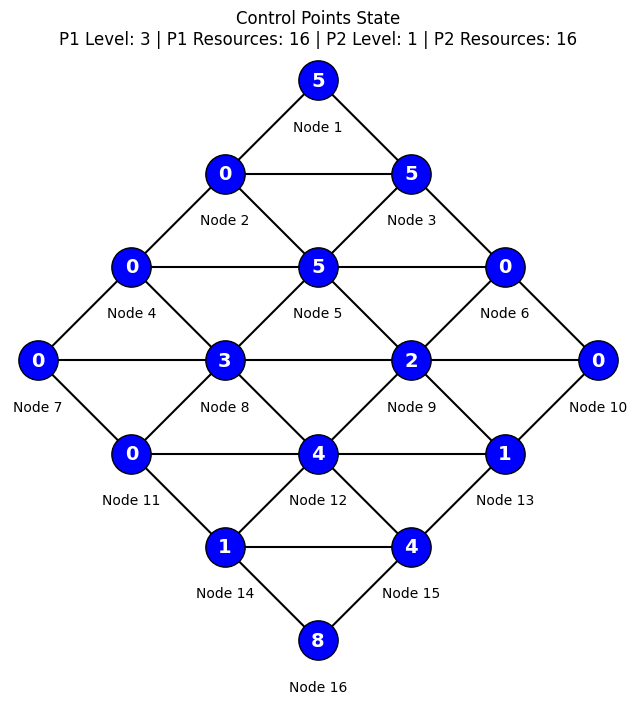

In [59]:
# Play a match against the trained AI!
# If you have an adblocker this could glitch and not show the input option
game = controlPoints(p1type='human', p2type='AI', p1agent=None, p2agent=agent_B, agent1_id=None, agent2_id='B', seed=30001)

game.playGame()